# Donor ecosystem analysis — Lighthouse nonprofit

**Role:** Nonprofit data strategist  
**Data:** `supporters`, `donations`, `donation_allocations`, `in_kind_donation_items`, `social_media_posts` (referral attribution)

This notebook segments donors, evaluates acquisition and campaigns, maps funding to safehouses and programs, tests social engagement vs. giving, and ends with dashboard KPIs and product ideas focused on growth and retention.

## Setup

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

DATA_DIR = Path("lighthouse_csv_v7")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Data folder not found: {DATA_DIR.resolve()} - run from the INTEXII project root."
    )

supporters = pd.read_csv(
    DATA_DIR / "supporters.csv",
    parse_dates=["created_at", "first_donation_date"],
)
donations = pd.read_csv(
    DATA_DIR / "donations.csv",
    parse_dates=["donation_date"],
)
donation_allocations = pd.read_csv(
    DATA_DIR / "donation_allocations.csv",
    parse_dates=["allocation_date"],
)
in_kind_donation_items = pd.read_csv(DATA_DIR / "in_kind_donation_items.csv")
social_media_posts = pd.read_csv(
    DATA_DIR / "social_media_posts.csv",
    parse_dates=["created_at"],
)
safehouses = pd.read_csv(DATA_DIR / "safehouses.csv")

AS_OF = donations["donation_date"].max()
print("Analysis as-of date (latest gift):", AS_OF.date())
pd.DataFrame(
    {
        "rows": [
            len(supporters),
            len(donations),
            len(donation_allocations),
            len(in_kind_donation_items),
            len(social_media_posts),
        ]
    },
    index=[
        "supporters",
        "donations",
        "donation_allocations",
        "in_kind_donation_items",
        "social_media_posts",
    ],
)

Analysis as-of date (latest gift): 2026-03-01


,rows
supporters,60
donations,420
donation_allocations,521
in_kind_donation_items,129
social_media_posts,812


In [ ]:
def donation_value_php(row: pd.Series) -> float:
    """Comparable PHP value for monetary + in-kind rows (time/skills excluded from PHP totals)."""
    if row["donation_type"] == "Monetary" and pd.notna(row["amount"]):
        return float(row["amount"])
    if row["donation_type"] == "InKind" and pd.notna(row["estimated_value"]):
        return float(row["estimated_value"])
    return 0.0


donations = donations.copy()
donations["value_php"] = donations.apply(donation_value_php, axis=1)
donations["has_monetary_or_inkind_value"] = donations["value_php"] > 0

## 1. ML-based supporter segmentation + churn prediction

> **Production churn pipeline:** see `Donor_Churn_Analysis.ipynb` for leakage-safe panel labels, time-grouped CV, baselines, risk tiers, and stakeholder sections.

This section replaces manual, rule-based segmentation with formal machine learning:

- **Segmentation (unsupervised):**
  - Uses **K-Means** when only numeric donor features are used.
  - Uses **Hierarchical Clustering** with **Gower-style mixed distance** when both numeric and categorical features are included.
- **Churn prediction (supervised):**
  - Builds a supporter-level dataset at a historical cut date.
  - Trains a **Random Forest** classifier on a held-out train/test split.
  - Evaluates predictive performance and ranks retention drivers with **Permutation Feature Importance (PFI)**.

All transformations are performed on copied DataFrames so source inputs are not mutated.

Segmentation model used: kmeans_numeric


,supporters,avg_lifetime_php,median_days_since_last,recurring_share
segment_cluster,,,,
1,15,9817.50,63.0,0.800
3,3,8009.45,215.0,0.000
2,28,3390.71,105.0,0.143
0,14,1872.31,413.0,0.143


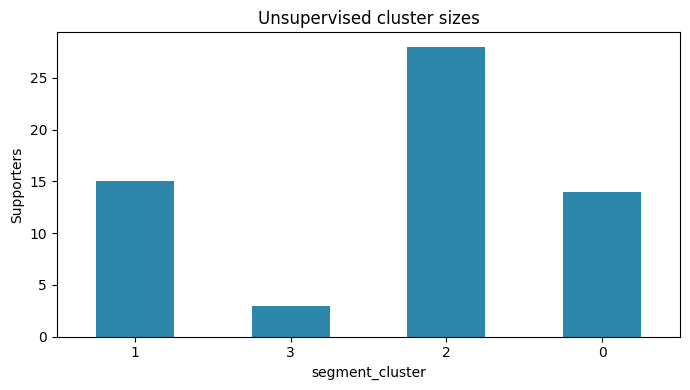

Held-out churn model performance (comparison):


,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
model,,,,,,
Random Forest,0.778,0.733,0.667,0.571,0.667,0.615
Logistic Regression,0.389,0.374,0.400,0.333,0.500,0.400



Classification report (test) - Random Forest:
              precision    recall  f1-score   support

           0      0.750     0.667     0.706         9
           1      0.571     0.667     0.615         6

    accuracy                          0.667        15
   macro avg      0.661     0.667     0.661        15
weighted avg      0.679     0.667     0.670        15


Classification report (test) - Logistic Regression:
              precision    recall  f1-score   support

           0      0.500     0.333     0.400         9
           1      0.333     0.500     0.400         6

    accuracy                          0.400        15
   macro avg      0.417     0.417     0.400        15
weighted avg      0.433     0.400     0.400        15


Top retention/churn drivers from PFI - Random Forest:


,feature,importance_mean,importance_std
0,days_between_first_last_gift,0.158519,0.097017
1,lifetime_value_php,0.060741,0.091102
2,max_gift_php,0.031852,0.041415
3,gift_count,0.028889,0.031023
4,days_since_last_gift,0.017778,0.041732
5,avg_gift_php,0.015556,0.069622
6,has_recurring,-0.002222,0.025831
7,primary_campaign,-0.002222,0.006018
8,campaign_diversity,-0.005926,0.053855
9,acquisition_channel,-0.100741,0.031462


Acquisition channel and campaign importance - Random Forest:


,feature,importance_mean,importance_std
7,primary_campaign,-0.002222,0.006018
9,acquisition_channel,-0.100741,0.031462



Top retention/churn drivers from PFI - Logistic Regression:


,feature,importance_mean,importance_std
0,lifetime_value_php,0.040741,0.061531
1,has_recurring,0.026667,0.050804
2,primary_campaign,0.023704,0.030325
3,days_between_first_last_gift,0.008889,0.048607
4,avg_gift_php,0.000000,0.000000
5,gift_count,-0.000741,0.063609
6,days_since_last_gift,-0.015556,0.023236
7,max_gift_php,-0.028148,0.015818
8,acquisition_channel,-0.071111,0.095248
9,campaign_diversity,-0.129630,0.120014


Acquisition channel and campaign importance - Logistic Regression:


,feature,importance_mean,importance_std
2,primary_campaign,0.023704,0.030325
8,acquisition_channel,-0.071111,0.095248


In [ ]:
def build_supporter_snapshot(
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    as_of_date: pd.Timestamp,
) -> pd.DataFrame:
    """Create supporter-level features from donations up to as_of_date without mutating inputs."""
    d = donations_df.copy()
    s = supporters_df.copy()

    d = d.loc[d["donation_date"] <= as_of_date].copy()

    agg = (
        d.groupby("supporter_id")
        .agg(
            lifetime_value_php=("value_php", "sum"),
            gift_count=("donation_id", "count"),
            avg_gift_php=("value_php", "mean"),
            max_gift_php=("value_php", "max"),
            has_recurring=("is_recurring", "max"),
            first_gift=("donation_date", "min"),
            last_gift=("donation_date", "max"),
            campaign_diversity=("campaign_name", "nunique"),
        )
        .reset_index()
    )

    # Supporter's dominant campaign up to the snapshot date.
    d_campaign = d.copy()
    d_campaign["campaign_name"] = d_campaign["campaign_name"].fillna("(No campaign name)").replace("", "(No campaign name)")
    dominant_campaign = (
        d_campaign.groupby(["supporter_id", "campaign_name"])["donation_id"]
        .count()
        .rename("campaign_count")
        .reset_index()
        .sort_values(["supporter_id", "campaign_count", "campaign_name"], ascending=[True, False, True])
        .drop_duplicates(subset=["supporter_id"])[["supporter_id", "campaign_name"]]
        .rename(columns={"campaign_name": "primary_campaign"})
    )

    snapshot = s.merge(agg, on="supporter_id", how="left").merge(dominant_campaign, on="supporter_id", how="left")

    snapshot["lifetime_value_php"] = snapshot["lifetime_value_php"].fillna(0.0)
    snapshot["gift_count"] = snapshot["gift_count"].fillna(0).astype(int)
    snapshot["avg_gift_php"] = snapshot["avg_gift_php"].fillna(0.0)
    snapshot["max_gift_php"] = snapshot["max_gift_php"].fillna(0.0)
    snapshot["campaign_diversity"] = snapshot["campaign_diversity"].fillna(0).astype(int)
    # Keep as numeric 0/1 for downstream ML preprocessing stability.
    snapshot["has_recurring"] = snapshot["has_recurring"].fillna(False).astype(int)

    snapshot["days_since_last_gift"] = np.where(
        snapshot["last_gift"].notna(),
        (as_of_date - snapshot["last_gift"]).dt.days,
        np.nan,
    )
    snapshot["days_between_first_last_gift"] = np.where(
        snapshot["first_gift"].notna() & snapshot["last_gift"].notna(),
        (snapshot["last_gift"] - snapshot["first_gift"]).dt.days,
        0,
    )

    snapshot["acquisition_channel"] = (
        snapshot["acquisition_channel"].fillna("Unknown").replace("", "Unknown")
    )
    snapshot["primary_campaign"] = (
        snapshot["primary_campaign"].fillna("(No campaign name)").replace("", "(No campaign name)")
    )
    return snapshot


def _gower_distance_matrix(frame: pd.DataFrame, numeric_cols: list[str], categorical_cols: list[str]) -> np.ndarray:
    """Compute a simple Gower-style pairwise distance matrix for mixed data."""
    n_rows = len(frame)
    dist = np.zeros((n_rows, n_rows), dtype=float)

    if numeric_cols:
        num = frame[numeric_cols].copy()
        for c in numeric_cols:
            num[c] = num[c].fillna(num[c].median())
        ranges = (num.max() - num.min()).replace(0, 1)
        num = num / ranges
        num_vals = num.to_numpy(dtype=float)
        for i in range(n_rows):
            dist[i, :] += np.abs(num_vals[i] - num_vals).mean(axis=1)

    if categorical_cols:
        cat = frame[categorical_cols].copy().fillna("Missing").astype(str)
        cat_vals = cat.to_numpy(dtype=object)
        for i in range(n_rows):
            dist[i, :] += (cat_vals[i] != cat_vals).mean(axis=1)

    feature_groups = int(bool(numeric_cols)) + int(bool(categorical_cols))
    if feature_groups == 0:
        raise ValueError("At least one numeric or categorical column is required for clustering.")

    return dist / feature_groups


def cluster_supporters(
    supporter_snapshot: pd.DataFrame,
    n_clusters: int = 4,
    categorical_cols: list[str] | None = None,
) -> tuple[pd.DataFrame, str]:
    """
    Cluster supporters without mutating the input.
    - K-Means for numeric-only features.
    - Hierarchical clustering + Gower distance for mixed numeric/categorical features.
    """
    df = supporter_snapshot.copy()

    numeric_cols = [
        "lifetime_value_php",
        "gift_count",
        "avg_gift_php",
        "max_gift_php",
        "days_since_last_gift",
        "days_between_first_last_gift",
        "campaign_diversity",
    ]

    if categorical_cols is None:
        categorical_cols = []

    if categorical_cols:
        dmat = _gower_distance_matrix(df[numeric_cols + categorical_cols], numeric_cols, categorical_cols)
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric="precomputed",
            linkage="average",
        )
        labels = model.fit_predict(dmat)
        method = "hierarchical_gower"
    else:
        X_num = df[numeric_cols].copy()
        X_num = X_num.fillna(X_num.median(numeric_only=True))
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_num)
        model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X_scaled)
        method = "kmeans_numeric"

    out = df.copy()
    out["segment_cluster"] = labels
    return out, method


def build_churn_dataset(
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    as_of_date: pd.Timestamp,
    horizon_days: int = 180,
) -> pd.DataFrame:
    """Build historical feature rows and churn labels at a cut date."""
    cutoff = as_of_date - pd.Timedelta(days=horizon_days)

    history_snapshot = build_supporter_snapshot(
        donations_df=donations_df,
        supporters_df=supporters_df,
        as_of_date=cutoff,
    )

    d = donations_df.copy()
    future = d[(d["donation_date"] > cutoff) & (d["donation_date"] <= as_of_date)].copy()
    future_positive = (
        future.groupby("supporter_id")["value_php"].sum().rename("future_value_php").reset_index()
    )

    labeled = history_snapshot.merge(future_positive, on="supporter_id", how="left")
    labeled["future_value_php"] = labeled["future_value_php"].fillna(0.0)

    # churn=1 means no positive donation value in the next horizon window.
    labeled = labeled[labeled["gift_count"] > 0].copy()
    labeled["churn_label"] = (labeled["future_value_php"] <= 0).astype(int)
    return labeled


# ------------------------
# 1A) Unsupervised segmentation
# ------------------------
supporter_snapshot = build_supporter_snapshot(
    donations_df=donations,
    supporters_df=supporters,
    as_of_date=AS_OF,
)

# Numeric-only K-Means (required default). Add categorical columns to use hierarchical+Gower.
clustered_supporters, cluster_method = cluster_supporters(
    supporter_snapshot=supporter_snapshot,
    n_clusters=4,
    categorical_cols=[],
)

cluster_summary = (
    clustered_supporters.groupby("segment_cluster")
    .agg(
        supporters=("supporter_id", "count"),
        avg_lifetime_php=("lifetime_value_php", "mean"),
        median_days_since_last=("days_since_last_gift", "median"),
        recurring_share=("has_recurring", "mean"),
    )
    .sort_values("avg_lifetime_php", ascending=False)
)
cluster_summary["avg_lifetime_php"] = cluster_summary["avg_lifetime_php"].round(2)
cluster_summary["recurring_share"] = cluster_summary["recurring_share"].round(3)

print(f"Segmentation model used: {cluster_method}")
display(cluster_summary)

fig, ax = plt.subplots(figsize=(7, 4))
cluster_summary["supporters"].plot(kind="bar", ax=ax, color="#2E86AB")
ax.set_ylabel("Supporters")
ax.set_title("Unsupervised cluster sizes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Keep `seg` for downstream notebook sections.
seg = clustered_supporters.copy()


# ------------------------
# 1B) Predictive churn model + held-out evaluation + PFI
# ------------------------
churn_df = build_churn_dataset(
    donations_df=donations,
    supporters_df=supporters,
    as_of_date=AS_OF,
    horizon_days=180,
)

feature_cols = [
    "lifetime_value_php",
    "gift_count",
    "avg_gift_php",
    "max_gift_php",
    "days_since_last_gift",
    "days_between_first_last_gift",
    "campaign_diversity",
    "has_recurring",
    "acquisition_channel",
    "primary_campaign",
]

X = churn_df[feature_cols].copy()
y = churn_df["churn_label"].copy()

numeric_features = [
    "lifetime_value_php",
    "gift_count",
    "avg_gift_php",
    "max_gift_php",
    "days_since_last_gift",
    "days_between_first_last_gift",
    "campaign_diversity",
    "has_recurring",
]
categorical_features = ["acquisition_channel", "primary_campaign"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)

logreg_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

models = {
    "Random Forest": rf_model,
    "Logistic Regression": logreg_model,
}

model_metrics = []
model_reports = {}
pfi_by_model = {}

for model_name, model_pipe in models.items():
    model_pipe.fit(X_train, y_train)
    proba_test = model_pipe.predict_proba(X_test)[:, 1]
    pred_test = (proba_test >= 0.5).astype(int)

    model_metrics.append(
        {
            "model": model_name,
            "ROC-AUC": roc_auc_score(y_test, proba_test),
            "PR-AUC": average_precision_score(y_test, proba_test),
            "Accuracy": accuracy_score(y_test, pred_test),
            "Precision": precision_score(y_test, pred_test, zero_division=0),
            "Recall": recall_score(y_test, pred_test, zero_division=0),
            "F1": f1_score(y_test, pred_test, zero_division=0),
        }
    )

    model_reports[model_name] = classification_report(
        y_test,
        pred_test,
        digits=3,
        zero_division=0,
    )

    pfi = permutation_importance(
        model_pipe,
        X_test,
        y_test,
        n_repeats=25,
        random_state=RANDOM_STATE,
        scoring="roc_auc",
    )
    pfi_ranked = (
        pd.DataFrame(
            {
                "feature": X_test.columns,
                "importance_mean": pfi.importances_mean,
                "importance_std": pfi.importances_std,
            }
        )
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )
    pfi_by_model[model_name] = pfi_ranked

metrics_table = pd.DataFrame(model_metrics).set_index("model").round(3)

print("Held-out churn model performance (comparison):")
display(metrics_table)

for model_name in models:
    print(f"\nClassification report (test) - {model_name}:")
    print(model_reports[model_name])

for model_name in models:
    print(f"\nTop retention/churn drivers from PFI - {model_name}:")
    display(pfi_by_model[model_name])

    channel_campaign_pfi = pfi_by_model[model_name][
        pfi_by_model[model_name]["feature"].isin(["acquisition_channel", "primary_campaign"])
    ].copy()
    print(f"Acquisition channel and campaign importance - {model_name}:")
    display(channel_campaign_pfi)

# Keep Random Forest as the default reference model for downstream reuse.
churn_model = rf_model

## 2. Acquisition channel performance

We attribute revenue to `supporters.acquisition_channel` and compare **lifetime PHP** (monetary + in-kind) and **supporter counts**.

,supporters,lifetime_php,median_lifetime_php,php_per_supporter
acquisition_channel,,,,
SocialMedia,13,85132.13,4713.840,6548.63
WordOfMouth,14,54596.89,3723.495,3899.78
Event,8,38906.22,4132.645,4863.28
Church,6,38668.07,6662.080,6444.68
Website,13,38526.17,2115.540,2963.55
PartnerReferral,6,36613.47,3497.705,6102.24


Largest total raised: SocialMedia. Highest PHP per acquired supporter: SocialMedia.


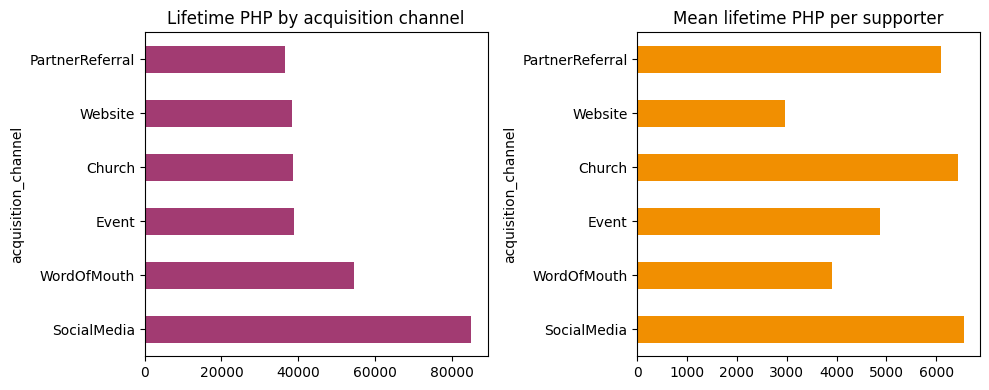

In [ ]:
ch = (
    seg.groupby("acquisition_channel", dropna=False)
    .agg(
        supporters=("supporter_id", "count"),
        lifetime_php=("lifetime_value_php", "sum"),
        median_lifetime_php=("lifetime_value_php", "median"),
    )
    .sort_values("lifetime_php", ascending=False)
)
ch["php_per_supporter"] = (ch["lifetime_php"] / ch["supporters"]).round(2)

# Aliases for downstream summary sections.
acquisition_perf = ch.copy()
acq = ch.copy()

display(ch)

best_by_total = ch.index[0]
best_by_efficiency = ch["php_per_supporter"].idxmax()
print(
    f"Largest total raised: {best_by_total}. Highest PHP per acquired supporter: {best_by_efficiency}."
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ch["lifetime_php"].plot(kind="barh", ax=axes[0], color="#A23B72")
axes[0].set_title("Lifetime PHP by acquisition channel")
ch["php_per_supporter"].plot(kind="barh", ax=axes[1], color="#F18F01")
axes[1].set_title("Mean lifetime PHP per supporter")
plt.tight_layout()
plt.show()

## 3. Campaign value

We sum `value_php` by `campaign_name` on donation rows (blank campaign = **General / unspecified**).

,total_php,gifts,php_per_gift
campaign,,,
(No campaign name),188038.52,275,683.78
Year-End Hope,45251.70,60,754.20
Back to School,24071.48,32,752.23
Summer of Safety,21901.78,35,625.77
GivingTuesday,13179.47,18,732.19


Top campaign by total PHP: (No campaign name)


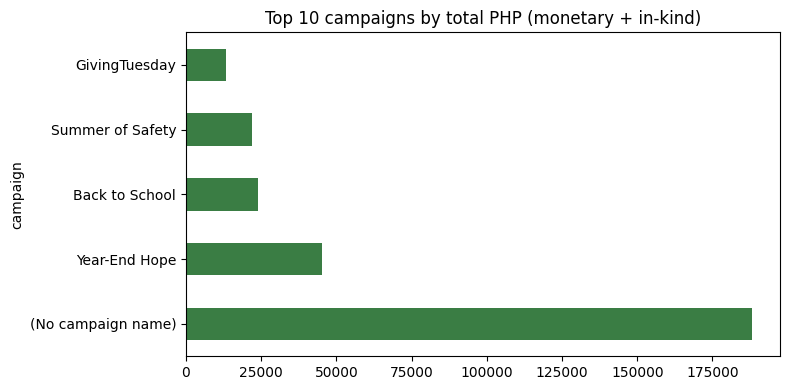

In [ ]:
camp = donations.copy()
camp["campaign"] = camp["campaign_name"].fillna("(No campaign name)").replace("", "(No campaign name)")
campaign_value = (
    camp.groupby("campaign")
    .agg(total_php=("value_php", "sum"), gifts=("donation_id", "count"))
    .sort_values("total_php", ascending=False)
)
campaign_value["php_per_gift"] = (campaign_value["total_php"] / campaign_value["gifts"]).round(2)
display(campaign_value.head(15))

top_campaign = campaign_value.index[0]
print(f"Top campaign by total PHP: {top_campaign}")

fig, ax = plt.subplots(figsize=(8, 4))
campaign_value.head(10)["total_php"].plot(kind="barh", ax=ax, color="#3A7D44")
ax.set_title("Top 10 campaigns by total PHP (monetary + in-kind)")
plt.tight_layout()
plt.show()

## 4. Safehouses and program areas — funding concentration

Using `donation_allocations.amount_allocated` joined to safehouse names.

Top safehouses by allocated PHP:


,,allocated_php
safehouse_id,name,
3,Lighthouse Safehouse 3,50574.33
1,Lighthouse Safehouse 1,34689.26
2,Lighthouse Safehouse 2,34363.02
4,Lighthouse Safehouse 4,34335.76
8,Lighthouse Safehouse 8,34134.29
7,Lighthouse Safehouse 7,30196.11
5,Lighthouse Safehouse 5,23996.23
9,Lighthouse Safehouse 9,20932.77
6,Lighthouse Safehouse 6,19214.62


Program areas:


,share_of_total
program_area,
Education,0.238
Operations,0.237
Wellbeing,0.187
Transport,0.138
Maintenance,0.106
Outreach,0.093


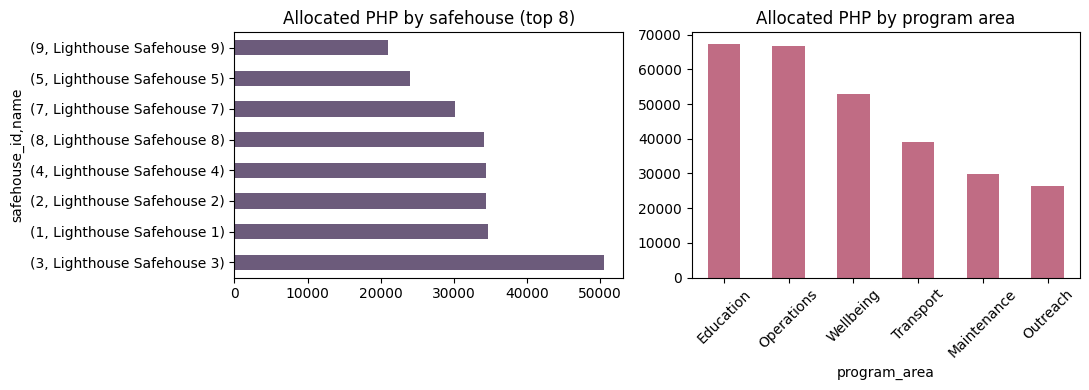

In [ ]:
alloc_named = donation_allocations.merge(
    safehouses[["safehouse_id", "name", "region"]], on="safehouse_id", how="left"
)

by_safehouse = (
    alloc_named.groupby(["safehouse_id", "name"], dropna=False)["amount_allocated"]
    .sum()
    .sort_values(ascending=False)
)
by_program = (
    donation_allocations.groupby("program_area")["amount_allocated"]
    .sum()
    .sort_values(ascending=False)
)

print("Top safehouses by allocated PHP:")
display(by_safehouse.head(10).to_frame("allocated_php"))
print("Program areas:")
display((by_program / by_program.sum()).round(3).to_frame("share_of_total"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
by_safehouse.head(8).plot(kind="barh", ax=axes[0], color="#6C5B7B")
axes[0].set_title("Allocated PHP by safehouse (top 8)")
by_program.plot(kind="bar", ax=axes[1], color="#C06C84")
axes[1].set_title("Allocated PHP by program area")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5. Gaps in funding allocation

We highlight **concentration risk** (Herfindahl-style), **safehouses below median allocation**, and **program areas** with low share vs median — useful gap questions for leadership.

In [ ]:
total_alloc = donation_allocations["amount_allocated"].sum()
sh_share = by_safehouse / total_alloc
hhi_safehouses = float((sh_share**2).sum())
prog_share = by_program / total_alloc
hhi_programs = float((prog_share**2).sum())

median_sh = by_safehouse.median()
underfunded_sh = by_safehouse[by_safehouse < median_sh].sort_values()

median_prog = by_program.median()
underfunded_prog = by_program[by_program < median_prog].sort_values()

gap_summary = pd.DataFrame(
    {
        "metric": [
            "HHI safehouses (1/n perfect equality)",
            "HHI program areas",
            "Safehouses below median allocation",
            "Program areas below median allocation",
        ],
        "value": [hhi_safehouses, hhi_programs, len(underfunded_sh), len(underfunded_prog)],
    }
)
display(gap_summary)

print("Safehouses receiving less than median allocated PHP:")
display(underfunded_sh.to_frame("allocated_php"))
print("Program areas below median:")
display(underfunded_prog.to_frame("allocated_php"))

,metric,value
0,HHI safehouses (1/n perfect equality),0.120108
1,HHI program areas,0.187009
2,Safehouses below median allocation,4.000000
3,Program areas below median allocation,3.000000


Safehouses receiving less than median allocated PHP:


,,allocated_php
safehouse_id,name,
6,Lighthouse Safehouse 6,19214.62
9,Lighthouse Safehouse 9,20932.77
5,Lighthouse Safehouse 5,23996.23
7,Lighthouse Safehouse 7,30196.11


Program areas below median:


,allocated_php
program_area,
Outreach,26381.31
Maintenance,29894.24
Transport,39052.78


### In-kind items (detail)

Line-level `in_kind_donation_items` describes **what** was donated; PHP is modeled on the parent `donations` row. Below: activity by **item category**.

In [ ]:
ink = in_kind_donation_items.merge(
    donations[["donation_id", "supporter_id"]], on="donation_id", how="left"
)
by_cat = (
    ink.groupby("item_category")
    .agg(lines=("item_id", "count"), total_qty=("quantity", "sum"))
    .sort_values("lines", ascending=False)
)
display(by_cat.head(12))

,lines,total_qty
item_category,,
Supplies,23,347
SchoolMaterials,22,341
Clothing,20,347
Medical,20,321
Food,15,247
Hygiene,15,150
Furniture,14,190


## Advanced — Social engagement and donations

### Referral-linked gifts

`donations.referral_post_id` joins to `social_media_posts.post_id` for attributed gifts.

Correlation of gift PHP with post metrics (referral rows only):


engagement_rate    0.038
likes             -0.126
impressions       -0.157
comments          -0.159
reach             -0.160
shares            -0.194
Name: value_php, dtype: float64

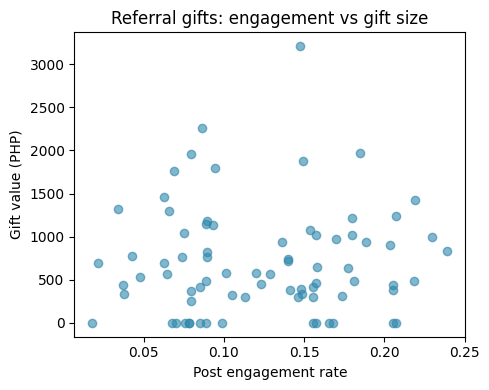

In [ ]:
ref = donations[donations["referral_post_id"].notna()].copy()
ref["referral_post_id"] = ref["referral_post_id"].astype(int)
posts_idx = social_media_posts.set_index("post_id")
ref_posts = ref.join(posts_idx, on="referral_post_id", rsuffix="_post")

cols = [
    "engagement_rate",
    "likes",
    "comments",
    "shares",
    "impressions",
    "reach",
]
corr = ref_posts[["value_php"] + [c for c in cols if c in ref_posts.columns]].corr(numeric_only=True)[
    "value_php"
].drop("value_php")
print("Correlation of gift PHP with post metrics (referral rows only):")
display(corr.sort_values(ascending=False).round(3))

if len(ref_posts) > 2:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(ref_posts["engagement_rate"], ref_posts["value_php"], alpha=0.6, color="#2E86AB")
    ax.set_xlabel("Post engagement rate")
    ax.set_ylabel("Gift value (PHP)")
    ax.set_title("Referral gifts: engagement vs gift size")
    plt.tight_layout()
    plt.show()

### Which post types lead to donations?

We aggregate **count** and **sum PHP** of referral-linked gifts by `post_type`.

,referral_gifts,total_php
post_type,,
ImpactStory,34,21646.78
FundraisingAppeal,18,13008.63
Campaign,11,8521.30
EventPromotion,6,4881.52
EducationalContent,5,3566.79
ThankYou,3,2499.00


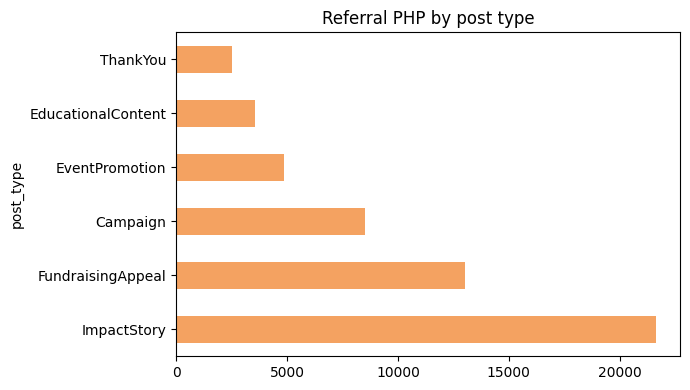

In [ ]:
if len(ref_posts):
    by_post_type = (
        ref_posts.groupby("post_type")
        .agg(referral_gifts=("donation_id", "count"), total_php=("value_php", "sum"))
        .sort_values("total_php", ascending=False)
    )
    display(by_post_type)
else:
    print("No referral-linked rows to summarize.")

fig, ax = plt.subplots(figsize=(7, 4))
if len(ref_posts):
    by_post_type["total_php"].head(10).plot(kind="barh", ax=ax, color="#F4A261")
    ax.set_title("Referral PHP by post type")
    plt.tight_layout()
    plt.show()

## Strategy — KPIs for a donor dashboard

| KPI | Why it matters |
|-----|----------------|
| **New donors / month** by acquisition channel | Ties marketing spend and partnerships to pipeline. |
| **Retention rate** (% giving again within 12 months) | Core health metric for recurring vs one-time mix. |
| **Median days between gifts** (by segment) | Early warning for at-risk before hard churn. |
| **Lifetime value (LTV) proxy** — rolling 24-month PHP | Prioritizes stewardship for high-value segments. |
| **% revenue with campaign tag** | Disciplines campaign ROI and naming. |
| **Allocation coverage** — % of PHP mapped to program + safehouse | Surfaces operational blind spots. |
| **Referral-attributed PHP** and **posts per PHP** | Quantifies social proof and paid/organic social impact. |
| **Concentration index** (HHI) for program/safehouse | Flags over-reliance on one site or line item. |

---

## Three donor-facing app features (growth + retention)

1. **Personal impact timeline** — show each donor how allocations flowed to program areas and safehouses (using allocation data), with optional story snippets from posts that matched their referral or interests. *Drives retention through transparency and emotional connection.*

2. **Smart giving nudges** — based on segment (e.g. at-risk: “pick a monthly top-up”; recurring: “add an emergency fund round-up”; one-time: “try a 3-month pledge”). *Converts one-time to recurring and reactivates lapsed donors.*

3. **Community + campaigns hub** — live campaign progress, leaderboards by *opt-in* teams, and shareable social assets tied to post types that historically drive referrals. *Acquisition through peer networks and measurable campaign virality.*

---

**Growth + retention narrative:** Double down on acquisition channels with **strong PHP per supporter**, run **named campaigns** with clear tags for ROI, and **rebalance** allocations where safehouses or programs sit below median while monitoring concentration. Pair **social content types** that drive referral PHP with paid boosting tests, and operationalize **recency** alerts for at-risk donors before they fully lapse.

## Key results

This section summarizes the most important findings from the notebook for quick decision-making.

- Focus on **predictive retention** metrics (held-out churn performance) for model quality.
- Use **PFI rankings** to identify which supporter attributes, acquisition channels, and campaigns are most associated with retention outcomes.
- Combine these ML findings with observed channel/campaign and referral analyses to guide budget and stewardship actions.

In [ ]:
# Auto-generated executive summary from computed notebook outputs.

print("=== KEY RESULTS SUMMARY ===")

# 1) Segmentation model + cluster patterns
if "cluster_method" in globals() and "cluster_summary" in globals():
    print(f"\n1) Segmentation approach: {cluster_method}")
    if len(cluster_summary):
        largest_cluster_id = cluster_summary["supporters"].idxmax()
        largest_cluster_size = int(cluster_summary.loc[largest_cluster_id, "supporters"])
        print(f"   - Largest cluster: {largest_cluster_id} ({largest_cluster_size} supporters)")
        print("   - Cluster profile snapshot:")
        display(cluster_summary)
else:
    print("\n1) Segmentation results not found in current kernel state.")

# 2) Held-out churn performance comparison
if "metrics_table" in globals():
    print("\n2) Held-out churn model performance (test set):")
    display(metrics_table)

    if "ROC-AUC" in metrics_table.columns:
        best_model = metrics_table["ROC-AUC"].idxmax()
        best_auc = float(metrics_table.loc[best_model, "ROC-AUC"])
        print(f"   - Best model by ROC-AUC: {best_model} ({best_auc:.3f})")
else:
    print("\n2) Churn performance table not found in current kernel state.")

# 3) Retention drivers from PFI
if "pfi_by_model" in globals() and isinstance(pfi_by_model, dict) and len(pfi_by_model):
    print("\n3) Top retention/churn drivers (Permutation Feature Importance):")
    for model_name, pfi_df in pfi_by_model.items():
        print(f"   - {model_name} top drivers:")
        display(pfi_df.head(5))

        channel_campaign = pfi_df[pfi_df["feature"].isin(["acquisition_channel", "primary_campaign"])].copy()
        if len(channel_campaign):
            print(f"     Acquisition/campaign influence ({model_name}):")
            display(channel_campaign)
else:
    print("\n3) PFI outputs not found in current kernel state.")

# 4) Acquisition channel findings from descriptive analysis
if "acquisition_perf" in globals():
    print("\n4) Acquisition channel performance (descriptive):")
    display(acquisition_perf.head(10))
elif "acq" in globals():
    print("\n4) Acquisition channel performance (descriptive):")
    display(acq.head(10))
elif "ch" in globals():
    print("\n4) Acquisition channel performance (descriptive):")
    display(ch.head(10))
else:
    print("\n4) Acquisition channel summary table not found in current kernel state.")

# 5) Campaign findings from descriptive analysis
if "campaign_value" in globals():
    print("\n5) Campaign value (descriptive):")
    display(campaign_value.head(10))

    top_campaign_name = campaign_value.index[0] if len(campaign_value) else None
    if top_campaign_name is not None:
        print(f"   - Top campaign by total PHP: {top_campaign_name}")
else:
    print("\n5) Campaign value table not found in current kernel state.")

# 6) Social referral insights
if "by_post_type" in globals():
    print("\n6) Referral-linked donations by post type:")
    display(by_post_type)

    if len(by_post_type):
        top_post_type = by_post_type["total_php"].idxmax()
        top_post_php = float(by_post_type.loc[top_post_type, "total_php"])
        print(f"   - Top post type by referral PHP: {top_post_type} ({top_post_php:,.2f})")
else:
    print("\n6) Post-type referral summary not found in current kernel state.")

print("\n=== END KEY RESULTS ===")

=== KEY RESULTS SUMMARY ===

1) Segmentation approach: kmeans_numeric
   - Largest cluster: 2 (28 supporters)
   - Cluster profile snapshot:


,supporters,avg_lifetime_php,median_days_since_last,recurring_share
segment_cluster,,,,
1,15,9817.50,63.0,0.800
3,3,8009.45,215.0,0.000
2,28,3390.71,105.0,0.143
0,14,1872.31,413.0,0.143



2) Held-out churn model performance (test set):


,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
model,,,,,,
Random Forest,0.778,0.733,0.667,0.571,0.667,0.615
Logistic Regression,0.389,0.374,0.400,0.333,0.500,0.400


   - Best model by ROC-AUC: Random Forest (0.778)

3) Top retention/churn drivers (Permutation Feature Importance):
   - Random Forest top drivers:


...


5) Campaign value (descriptive):


,total_php,gifts,php_per_gift
campaign,,,
(No campaign name),188038.52,275,683.78
Year-End Hope,45251.70,60,754.20
Back to School,24071.48,32,752.23
Summer of Safety,21901.78,35,625.77
GivingTuesday,13179.47,18,732.19


   - Top campaign by total PHP: (No campaign name)

6) Referral-linked donations by post type:


,referral_gifts,total_php
post_type,,
ImpactStory,34,21646.78
FundraisingAppeal,18,13008.63
Campaign,11,8521.30
EventPromotion,6,4881.52
EducationalContent,5,3566.79
ThankYou,3,2499.00


   - Top post type by referral PHP: ImpactStory (21,646.78)

=== END KEY RESULTS ===
